In [19]:
"""
Engle-Granger 共整合配對交易滾動回測系統 (多參數網格搜索版)
核心功能：基於 Engle-Granger 二步驟共整合法的配對交易回測，支援多參數網格搜索與績效視覺化。

理論基礎：
  - Engle, R.F. & Granger, C.W.J. (1987). "Co-integration and Error Correction:
    Representation, Estimation, and Testing." Econometrica, 55(2), 251-276.

模組架構：
  ┌─────────────────────────────────────────────────────────────────┐
  │  Class 1: Formation  → ADF 單根檢定 + OLS 共整合回歸 + 殘差檢定 │
  │  Class 2: Trading    → Spread Z-Score 進出場邏輯                │
  │  Class 3: Performance→ CAGR / ExCAGR / Sharpe / MDD / 勝率      │
  │  Class 4: DataProcessor → 資料清理與前置處理                    │
  └─────────────────────────────────────────────────────────────────┘
"""

import sqlite3
import warnings
import itertools
import os
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

# statsmodels：ADF 單根檢定 + OLS 回歸
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore")


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# 全局類別常數
# ══════════════════════════════════════════════════════════════════════════════
MIN_TICKERS_FOR_PAIRING = 2   # 每個產業最少需要幾支股票才進行配對
ZSCORE_CLIP             = 10.0  # Z-Score 截斷上限，避免極端值影響訊號
MIN_SPREAD_STD          = 1e-6  # 防止除以零的最小標準差下限
ADF_PVALUE_I1           = 0.10  # I(1) 確認門檻：ADF p-value > 此值 → 接受單根 H0
ADF_PVALUE_COINTEGRATE  = 0.01  # 共整合確認門檻：殘差 ADF p-value < 此值 → 拒絕單根 H0
ADF_MAX_LAGS            = 5     # ADF 最大滯後階數（None = 自動 BIC 選擇）


# ══════════════════════════════════════════════════════════════════════════════
# Class 1：Formation（形成期模組） — Engle-Granger 二步驟共整合
# ══════════════════════════════════════════════════════════════════════════════
class Formation:
    """
    形成期：對每個股票對執行 Engle-Granger 二步驟共整合檢定。

    步驟一：ADF 單根檢定
        確認 Y 與 X 均為 I(1) 序列（即一階整合），
        若任一序列為 I(0)（本身穩態），則配對不滿足共整合前提，予以排除。

    步驟二：OLS 共整合回歸
        Y_t = α + β·X_t + ε_t
        β 稱為避險比率（hedge ratio），α 為截距（長期均衡水準）。

    步驟三：殘差 ADF 檢定
        若殘差 ε_t 為穩態 I(0)（ADF p < ADF_PVALUE_COINTEGRATE），
        則判定 Y 與 X 具有共整合關係 → 納入候選配對。
    """

    def __init__(
        self,
        price_df: pd.DataFrame,
        form_start: str,
        form_end: str,
        top_n: int = 20,
        sector_mapping: dict = None,
        max_half_life: float = 63.0,
    ):
        self.price_df     = price_df.copy()
        self.form_start   = form_start
        self.form_end     = form_end
        self.top_n        = top_n
        self.sector_mapping = sector_mapping or {}
        self.max_half_life  = max_half_life

        self.cointegration_records: list = []
        self.selected_pairs: pd.DataFrame = pd.DataFrame()

    # ------------------------------------------------------------------
    # 內部工具：殘差半衰期估計
    # ------------------------------------------------------------------
    @staticmethod
    def _calculate_half_life(resid: np.ndarray) -> float:
        """利用 Ornstein-Uhlenbeck 過程近似，計算殘差均值回歸的半衰期"""
        if len(resid) < 2:
            return np.inf
        resid_lag = np.roll(resid, 1)[1:]
        delta     = np.diff(resid)
        try:
            beta = np.polyfit(resid_lag, delta, 1)[0]
            return float(-np.log(2) / beta) if beta < 0 else np.inf
        except Exception:
            return np.inf

    # ------------------------------------------------------------------
    # 內部工具：ADF 單根檢定
    # ------------------------------------------------------------------
    @staticmethod
    def _adf_test(series: np.ndarray, maxlag: int = ADF_MAX_LAGS) -> tuple[float, float]:
        """
        對輸入序列執行 Augmented Dickey-Fuller 檢定。

        H0（虛無假設）：序列含有單根（非穩態）
        H1（對立假設）：序列不含單根（穩態）

        Args:
            series: 價格或殘差序列（numpy array）
            maxlag: ADF 最大滯後階數；None 則由 BIC 自動決定

        Returns:
            (adf_stat, p_value)
            - p_value > ADF_PVALUE_I1  → 接受 H0，序列為 I(1)（非穩態）✓
            - p_value < ADF_PVALUE_COINTEGRATE → 拒絕 H0，殘差穩態 → 共整合 ✓
        """
        try:
            result = adfuller(series, maxlag=maxlag, autolag="BIC", regression="c")
            return float(result[0]), float(result[1])
        except Exception:
            return np.nan, 1.0  # 檢定失敗時視為非穩態

    # ------------------------------------------------------------------
    # 核心：共整合篩選
    # ------------------------------------------------------------------
    def compute_cointegration(self) -> pd.DataFrame:
        """
        對所有股票對執行 Engle-Granger 二步驟共整合篩選：
        1. 確認 Y ~ I(1) 且 X ~ I(1)
        2. OLS 回歸取得 α, β
        3. 殘差 ADF 確認共整合
        按殘差 ADF p-value 由小到大排序（越小表示共整合關係越顯著）。
        """
        tickers = self.price_df.columns.tolist()
        self.cointegration_records = []

        # 建立產業分組
        if self.sector_mapping:
            sector_groups: dict = {}
            for ticker in tickers:
                sector = self.sector_mapping.get(ticker, "Unknown")
                sector_groups.setdefault(sector, []).append(ticker)
        else:
            sector_groups = {"All_Market": tickers}

        for sector, sector_tickers in sector_groups.items():
            if sector == "Unknown":
                continue
            if len(sector_tickers) < MIN_TICKERS_FOR_PAIRING:
                continue

            # ── Step 0：預先計算所有 ticker 的 ADF 結果（避免重複計算） ──
            adf_cache: dict[str, float] = {}
            for ticker in sector_tickers:
                series = np.log(self.price_df[ticker].dropna().values)
                if len(series) < 30:
                    adf_cache[ticker] = 0.0  # 資料不足，視為穩態（排除）
                else:
                    _, p_val = self._adf_test(series)
                    adf_cache[ticker] = p_val

            for ticker_a, ticker_b in itertools.combinations(sector_tickers, 2):
                # ── Step 1：ADF 單根檢定（確認兩序列均為 I(1)） ──
                # I(1) 判斷：p-value 大於門檻 → 接受單根 H0 → 非穩態 ✓
                p_a = adf_cache.get(ticker_a, 0.0)
                p_b = adf_cache.get(ticker_b, 0.0)

                if p_a <= ADF_PVALUE_I1 or p_b <= ADF_PVALUE_I1:
                    # 任一序列已為穩態（I(0)），不滿足 EG 共整合前提，跳過
                    continue

                # 取對數價格序列
                log_y = np.log(self.price_df[ticker_a].values)
                log_x = np.log(self.price_df[ticker_b].values)

                if np.any(np.isnan(log_y)) or np.any(np.isnan(log_x)):
                    continue

                # ── Step 2：OLS 共整合回歸 Y = α + β·X + ε ──
                # add_constant 為 X 加入截距項
                X_const = add_constant(log_x, has_constant="add")
                try:
                    ols_result = OLS(log_y, X_const).fit()
                except Exception:
                    continue

                alpha      = float(ols_result.params[0])   # 截距 α（長期均衡常數）
                beta       = float(ols_result.params[1])   # 避險比率 β（hedge ratio）
                r_squared  = float(ols_result.rsquared)    # 決定係數 R²

                # ── 計算殘差（價差序列） ──
                residuals = log_y - (alpha + beta * log_x)

                # ── Step 3：殘差 ADF 檢定（確認共整合關係） ──
                # 注意：Engle-Granger 第二步殘差 ADF 的臨界值與標準 ADF 不同，
                # 此處使用較嚴格的 p < 0.01 門檻以控制型一誤差。
                resid_adf_stat, resid_p_val = self._adf_test(residuals)

                if resid_p_val >= ADF_PVALUE_COINTEGRATE:
                    # 殘差仍含單根 → 不具共整合關係，跳過
                    continue

                # ── Step 4：半衰期過濾（過濾均值回歸太慢的配對） ──
                half_life = self._calculate_half_life(residuals)
                if half_life > self.max_half_life:
                    continue

                # ── 計算形成期殘差統計量（作為交易門檻基準） ──
                form_spread_mean = float(np.mean(residuals))   # μ_e
                form_spread_std  = float(np.std(residuals, ddof=1))  # σ_e

                self.cointegration_records.append({
                    "Form_Start"       : self.form_start,
                    "Form_End"         : self.form_end,
                    "Sector"           : sector,
                    "Ticker_A"         : ticker_a,   # Y（被解釋變數）
                    "Ticker_B"         : ticker_b,   # X（解釋變數）
                    "Alpha"            : round(alpha, 6),
                    "Hedge_Ratio"      : round(beta, 4),        # β
                    "Half_Life"        : round(half_life, 2),
                    "R_Squared"        : round(r_squared, 4),
                    "ADF_Resid_Stat"   : round(resid_adf_stat, 4),
                    "ADF_Resid_PValue" : round(resid_p_val, 6),  # 排序依據（越小越顯著）
                    "Form_Spread_Mean" : round(form_spread_mean, 6),  # μ_e
                    "Form_Spread_Std"  : round(form_spread_std, 6),   # σ_e
                    "ADF_PValue_A"     : round(p_a, 4),
                    "ADF_PValue_B"     : round(p_b, 4),
                })

        if not self.cointegration_records:
            return pd.DataFrame()

        # 按殘差 ADF p-value 升序排列（共整合關係越顯著越優先）
        return (
            pd.DataFrame(self.cointegration_records)
            .sort_values("ADF_Resid_PValue")
            .reset_index(drop=True)
        )

    def select_pairs(self) -> pd.DataFrame:
        """取前 top_n 組共整合配對，附上排名。"""
        coint_df = self.compute_cointegration()
        if coint_df.empty:
            self.selected_pairs = pd.DataFrame()
            return self.selected_pairs

        selected = coint_df.head(self.top_n).copy()
        selected["Rank"] = range(1, len(selected) + 1)
        self.selected_pairs = selected
        return self.selected_pairs

    def run(self) -> pd.DataFrame:
        return self.select_pairs()


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 2：Trading（交易期模組）
# ══════════════════════════════════════════════════════════════════════════════
@dataclass
class PairState:
    """單一配對在模擬過程中的內部狀態。"""
    position       : int   = 0
    shares_a       : float = 0.0
    shares_b       : float = 0.0
    entry_price_a  : float = 0.0
    entry_price_b  : float = 0.0
    realized_pnl   : float = 0.0
    trade_entry_fee: float = 0.0
    days_held      : int   = 0
    is_stopped     : bool  = False
    cooldown_dir   : int   = 0
    prev_total_pnl : float = 0.0


class Trading:
    """
    交易期：使用形成期估計的 (α, β, μ_e, σ_e) 計算交易期 Z-Score，
    並執行配對交易進出場邏輯。

    Spread 定義（EG 版本）：
        Spread_t = Y_t - (α + β·X_t)     [對數價格空間]
        Z_t = (Spread_t - μ_e) / σ_e

    進場：
        Z_t > +entry_z  → 放空價差（Short A / Long B）
        Z_t < -entry_z  → 做多價差（Long A / Short B）

    出場：
        Z_t 穿越 exit_z（通常為 0，即 Spread 回歸長期均衡） → 獲利平倉

    停損：
        單筆持倉虧損 / capital_per_pair ≥ stop_loss_pct → 強制平倉
    """

    def __init__(
        self,
        price_df        : pd.DataFrame,
        selected_pairs  : pd.DataFrame,
        capital_per_pair: float,
        fee_rate        : float,
        slippage_rate   : float,
        stop_loss_pct   : float,
        entry_z         : float,
        exit_z          : float,
        max_hold_days   : int  = 60,
        allow_reentry   : bool = False,
        zscore_window   : int  = 60,
    ):
        self.price_df         = price_df.copy()
        self.selected_pairs   = selected_pairs
        self.capital_per_pair = capital_per_pair
        self.friction_rate    = fee_rate + slippage_rate
        self.stop_loss_pct    = stop_loss_pct
        self.entry_z          = entry_z
        self.exit_z           = exit_z
        self.max_hold_days    = max_hold_days   # 強制平倉天數上限
        self.allow_reentry    = allow_reentry
        self.zscore_window    = zscore_window
        self.all_trade_logs   : list = []
        self.period_pnl       : float = 0.0

    # ------------------------------------------------------------------
    # 進場執行
    # ------------------------------------------------------------------
    def _execute_entry(
        self,
        state    : PairState,
        z        : float,
        p_a      : float,
        p_b      : float,
        beta     : float,
    ) -> tuple[bool, float]:
        """
        根據 Z-Score 方向決定做多/放空價差，並計算股數。

        資金分配：
            Beta 動態分配：
            A (被解釋變數 Y) 與 B (解釋變數 X) 的資金比例嚴格遵從 1 : |β|
            確保 OLS 求出的共整合關係中，殘差變異數能被完美對沖。
        """
        # Beta 動態分配資金比例 (A占 1/(1+|β|)，B占 |β|/(1+|β|))
        abs_beta = abs(beta)
        weight_a = 1.0 / (1.0 + abs_beta)
        weight_b = abs_beta / (1.0 + abs_beta)

        cap_a = self.capital_per_pair * weight_a
        cap_b = self.capital_per_pair * weight_b

        if z > self.entry_z and state.cooldown_dir != -1:
            # 放空價差：Y 過高 → 賣 Y（A），買 β 單位 X（B）
            state.position  = -1
            state.shares_a  = -cap_a / p_a                 # 做空 A
            state.shares_b  = cap_b * np.sign(beta) / p_b  # 做多 B (金額為 β 倍)
        elif z < -self.entry_z and state.cooldown_dir != 1:
            # 做多價差：Y 過低 → 買 Y（A），賣 β 單位 X（B）
            state.position  = +1
            state.shares_a  = cap_a / p_a                  # 做多 A
            state.shares_b  = -cap_b * np.sign(beta) / p_b # 做空 B (金額為 β 倍)
        else:
            return False, 0.0

        state.entry_price_a  = p_a
        state.entry_price_b  = p_b
        state.trade_entry_fee = (
            abs(state.shares_a) * p_a + abs(state.shares_b) * p_b
        ) * self.friction_rate
        state.days_held = 0
        return True, -state.trade_entry_fee

    # ------------------------------------------------------------------
    # 平倉執行
    # ------------------------------------------------------------------
    def _execute_close(self, state: PairState, current_trade_pnl: float, stop_loss: bool = False):
        """平倉：結算損益，更新狀態。"""
        state.realized_pnl += current_trade_pnl
        if stop_loss and not self.allow_reentry:
            state.is_stopped = True
        else:
            if self.allow_reentry:
                state.cooldown_dir = state.position  # 紀錄方向以避免立即回補
        state.position = 0

    # ------------------------------------------------------------------
    # 單配對模擬主函式
    # ------------------------------------------------------------------
    def _simulate_pair(
        self,
        sector          : str,
        ticker_a        : str,
        ticker_b        : str,
        pair_rank       : int,
        alpha           : float,   # OLS 截距 α
        beta            : float,   # 避險比率 β
        form_spread_mean: float,   # 形成期殘差均值 μ_e
        form_spread_std : float,   # 形成期殘差標準差 σ_e
        adf_pvalue      : float,   # 殘差 ADF p-value（記錄用）
    ) -> list:
        """
        交易期逐日模擬。

        Spread 計算（EG 版）：
            log_Y - (α + β·log_X)  — 在對數價格空間衡量偏離
        Z-Score：
            可動態選擇是否使用 rolling 統計量以解決樣本外均值漂移。
        """
        if ticker_a not in self.price_df.columns or ticker_b not in self.price_df.columns:
            return []

        price_a = self.price_df[ticker_a].dropna()
        price_b = self.price_df[ticker_b].dropna()
        common_idx = price_a.index.intersection(price_b.index)
        price_a = price_a.loc[common_idx]
        price_b = price_b.loc[common_idx]

        if len(price_a) < 5:
            return []

        # ── EG 版 Spread：Y_t - (α + β·X_t)（對數價格空間） ──
        log_p_a = np.log(price_a.values)
        log_p_b = np.log(price_b.values)
        spread   = log_p_a - (alpha + beta * log_p_b)

        # ── Z-Score 計算 ──
        spread_series = pd.Series(spread)
        if self.zscore_window == 0:
            safe_std = max(form_spread_std, MIN_SPREAD_STD)
            zscore = np.clip(
                (spread_series - form_spread_mean) / safe_std,
                -ZSCORE_CLIP, ZSCORE_CLIP
            ).values
        else:
            rolling_mean = spread_series.rolling(
                window=self.zscore_window,
                min_periods=max(10, self.zscore_window // 3)
            ).mean()
            rolling_std = spread_series.rolling(
                window=self.zscore_window,
                min_periods=max(10, self.zscore_window // 3)
            ).std().clip(lower=MIN_SPREAD_STD)
            zscore = np.clip(
                (spread_series - rolling_mean) / rolling_std,
                -ZSCORE_CLIP, ZSCORE_CLIP
            ).values

        dates_arr   = common_idx
        zscore_arr  = zscore
        pa_arr      = price_a.values
        pb_arr      = price_b.values

        # 靜態欄位字典（每日 log 共用）
        base_log = {
            "Sector"        : sector,
            "Pair_Rank"     : pair_rank,
            "Ticker_A"      : ticker_a,
            "Ticker_B"      : ticker_b,
            "Alpha"         : round(alpha, 6),
            "Hedge_Ratio"   : round(float(beta), 4),
            "Form_Spread_Mean": form_spread_mean,
            "Form_Spread_Std" : form_spread_std,
            "ADF_PValue"    : adf_pvalue,
        }

        state      = PairState()
        daily_logs = []

        for i in range(len(dates_arr)):
            date  = dates_arr[i]
            z     = 0.0 if np.isnan(zscore_arr[i]) else float(zscore_arr[i])
            p_a   = pa_arr[i]
            p_b   = pb_arr[i]

            unrealized_pnl    = 0.0
            closed_trade_pnl  = 0.0
            current_status    = "HOLD_CASH"

            # 已停損，不再交易
            if state.is_stopped:
                log_record = base_log.copy()
                log_record.update({
                    "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4),
                    "ZScore": round(z, 4), "Spread": round(float(spread[i]), 6),
                    "Position": 0, "Unrealized_PnL": 0.0,
                    "Realized_PnL": round(float(state.realized_pnl), 4),
                    "Cumulative_PnL": round(float(state.realized_pnl), 4),
                    "Status": "STOPPED", "Trade_PnL": 0.0,
                    "Days_Held": 0, "Daily_Delta": 0.0,
                })
                daily_logs.append(log_record)
                continue

            # 解除冷卻：等待價差回到合理區間
            if state.cooldown_dir == -1 and z <= self.exit_z:
                state.cooldown_dir = 0
            elif state.cooldown_dir == 1 and z >= -self.exit_z:
                state.cooldown_dir = 0

            if state.position != 0:
                state.days_held += 1

                # 計算浮動損益（含進場手續費，不含出場手續費）
                raw_unrealized = (
                    state.shares_a * (p_a - state.entry_price_a)
                    + state.shares_b * (p_b - state.entry_price_b)
                )
                exit_fee_est = (
                    abs(state.shares_a) * p_a + abs(state.shares_b) * p_b
                ) * self.friction_rate
                current_trade_pnl = raw_unrealized - state.trade_entry_fee - exit_fee_est

                # ── 停損觸發：虧損超過設定比例 ──
                if (-current_trade_pnl / self.capital_per_pair) >= self.stop_loss_pct:
                    self._execute_close(state, current_trade_pnl, stop_loss=True)
                    closed_trade_pnl = current_trade_pnl
                    current_status   = "STOP_LOSS_TRIGGERED"

                # ── 強制平倉：持倉超過 max_hold_days ──
                elif state.days_held >= self.max_hold_days:
                    self._execute_close(state, current_trade_pnl, stop_loss=False)
                    closed_trade_pnl = current_trade_pnl
                    current_status   = "FORCE_EXIT_MAX_DAYS"

                else:
                    # ── 正常出場：Z-Score 回歸至 exit_z（均值穿越） ──
                    is_exit_short = (state.position == -1) and (z <= self.exit_z)
                    is_exit_long  = (state.position == +1) and (z >= -self.exit_z)

                    if is_exit_short or is_exit_long:
                        self._execute_close(state, current_trade_pnl, stop_loss=False)
                        closed_trade_pnl = current_trade_pnl
                        current_status   = "EXIT"
                    else:
                        # 持倉中（未觸發出場條件）
                        unrealized_pnl = raw_unrealized - state.trade_entry_fee
                        current_status = "HOLDING"

            else:
                # 無持倉：檢查進場訊號
                if abs(z) > self.entry_z:
                    entered, unrealized_pnl = self._execute_entry(
                        state, z, p_a, p_b, beta
                    )
                    if entered:
                        current_status = "ENTER_SHORT_A" if state.position == -1 else "ENTER_LONG_A"
                    else:
                        current_status = "HOLD_CASH (COOLDOWN)"
                else:
                    current_status = "HOLD_CASH"

            # ── 累計損益與每日增量 ──
            cumulative_pnl = state.realized_pnl + unrealized_pnl
            daily_delta    = cumulative_pnl - state.prev_total_pnl
            state.prev_total_pnl = cumulative_pnl

            log_record = base_log.copy()
            log_record.update({
                "Date"          : date,
                "Price_A"       : round(p_a, 4),
                "Price_B"       : round(p_b, 4),
                "ZScore"        : round(z, 4),
                "Spread"        : round(float(spread[i]), 6),
                "Position"      : state.position,
                "Unrealized_PnL": round(float(unrealized_pnl), 4),
                "Realized_PnL"  : round(float(state.realized_pnl), 4),
                "Cumulative_PnL": round(float(cumulative_pnl), 4),
                "Status"        : current_status,
                "Trade_PnL"     : round(float(closed_trade_pnl), 4),
                "Days_Held"     : state.days_held,
                "Daily_Delta"   : round(float(daily_delta), 4),
            })
            daily_logs.append(log_record)

            # 清除當日計數
            if current_status in ("EXIT", "STOP_LOSS_TRIGGERED", "FORCE_EXIT_MAX_DAYS"):
                state.days_held = 0

        # ── 回測期末：強制平倉未結算部位 ──
        if state.position != 0 and daily_logs:
            last_s = daily_logs[-1]["Status"]
            if last_s not in ("EXIT", "STOP_LOSS_TRIGGERED", "FORCE_EXIT_MAX_DAYS",
                              "PERIOD_END_EXIT", "STOPPED"):
                pnl_before = daily_logs[-2]["Cumulative_PnL"] if len(daily_logs) > 1 else 0.0
                p_a_last, p_b_last = pa_arr[-1], pb_arr[-1]
                raw_final = (
                    state.shares_a * (p_a_last - state.entry_price_a)
                    + state.shares_b * (p_b_last - state.entry_price_b)
                )
                exit_fee = (
                    abs(state.shares_a) * p_a_last + abs(state.shares_b) * p_b_last
                ) * self.friction_rate
                closed_trade_pnl = raw_final - state.trade_entry_fee - exit_fee
                state.realized_pnl += closed_trade_pnl
                daily_delta = state.realized_pnl - pnl_before

                daily_logs[-1].update({
                    "Status"        : "PERIOD_END_EXIT",
                    "Realized_PnL"  : round(state.realized_pnl, 4),
                    "Cumulative_PnL": round(state.realized_pnl, 4),
                    "Unrealized_PnL": 0.0,
                    "Trade_PnL"     : round(closed_trade_pnl, 4),
                    "Daily_Delta"   : round(daily_delta, 4),
                    "Days_Held"     : state.days_held,
                })

        return daily_logs

    # ------------------------------------------------------------------
    # 執行所有配對
    # ------------------------------------------------------------------
    def run(self) -> tuple:
        self.all_trade_logs = []
        for _, row in self.selected_pairs.iterrows():
            logs = self._simulate_pair(
                sector           = row.get("Sector", "Unknown"),
                ticker_a         = row["Ticker_A"],
                ticker_b         = row["Ticker_B"],
                pair_rank        = int(row["Rank"]),
                alpha            = float(row.get("Alpha", 0.0)),
                beta             = float(row.get("Hedge_Ratio", 1.0)),
                form_spread_mean = float(row.get("Form_Spread_Mean", 0.0)),
                form_spread_std  = float(row.get("Form_Spread_Std", 1.0)),
                adf_pvalue       = float(row.get("ADF_Resid_PValue", 1.0)),
            )
            self.all_trade_logs.extend(logs)

        if not self.all_trade_logs:
            return pd.DataFrame(), pd.Series(dtype=float)

        log_df             = pd.DataFrame(self.all_trade_logs)
        period_daily_delta = log_df.groupby("Date")["Daily_Delta"].sum()
        self.period_pnl    = float(period_daily_delta.sum()) if not period_daily_delta.empty else 0.0

        return log_df, period_daily_delta


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 3：Performance（績效評估模組）
# ══════════════════════════════════════════════════════════════════════════════
class Performance:
    """
    績效評估模組。

    新增指標：
        ExCAGR（超額年化報酬率）：CAGR - 無風險利率（預設 5%）
        Calmar Ratio           ：CAGR / |Max Drawdown|
    """
    TRADING_DAYS_PER_YEAR = 252
    RISK_FREE_RATE        = 0.05    # 年化無風險利率（用於計算超額報酬）

    def __init__(self, initial_capital: float, output_dir: Path):
        self.initial_capital = initial_capital
        self.output_dir      = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.period_summaries  : list = []
        self.all_period_logs   : list = []
        self._global_daily_delta = pd.Series(dtype=float)
        self.equity_series       = pd.Series(dtype=float)
        self._entry_z = 2.0
        self._exit_z  = 0.0

        plt.rcParams.update({
            "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
            "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
            "axes.titlecolor": "#f0f6fc", "xtick.color": "#8b949e",
            "ytick.color": "#8b949e", "text.color": "#c9d1d9",
        })

    def set_zscore_params(self, entry_z: float, exit_z: float):
        self._entry_z = entry_z
        self._exit_z  = exit_z

    # ------------------------------------------------------------------
    # 新增期別資料
    # ------------------------------------------------------------------
    def add_period(
        self,
        period_start      : str,
        period_end        : str,
        trade_log_df      : pd.DataFrame,
        period_daily_delta: pd.Series,
        capital_deployed  : float,
        capital_per_pair  : float,
    ):
        if trade_log_df.empty or period_daily_delta.empty:
            return

        if self._global_daily_delta.empty:
            self._global_daily_delta = period_daily_delta
        else:
            self._global_daily_delta = self._global_daily_delta.add(
                period_daily_delta, fill_value=0.0
            )

        period_pnl_abs = float(period_daily_delta.sum())

        pair_traded = trade_log_df.groupby(["Ticker_A", "Ticker_B"])["Position"].apply(
            lambda x: (x != 0).any()
        )
        n_traded   = int(pair_traded.sum())
        n_nominated = len(pair_traded)

        r_cc = (period_pnl_abs / capital_deployed * 100) if capital_deployed > 0 else 0.0
        r_ec = (period_pnl_abs / (n_traded * capital_per_pair) * 100) if n_traded > 0 else 0.0

        exits = trade_log_df[
            trade_log_df["Status"].isin(
                ["EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT", "FORCE_EXIT_MAX_DAYS"]
            )
        ]
        exits = exits[exits["Trade_PnL"] != 0]
        trade_count      = len(exits)
        win_trades       = len(exits[exits["Trade_PnL"] > 0])
        gross_profit     = exits[exits["Trade_PnL"] > 0]["Trade_PnL"].sum()
        gross_loss       = abs(exits[exits["Trade_PnL"] < 0]["Trade_PnL"].sum())
        payoff_ratio     = (gross_profit / gross_loss) if gross_loss > 0 else np.nan
        avg_holding_days = exits["Days_Held"].mean() if trade_count > 0 else 0.0

        log_copy = trade_log_df.copy()
        log_copy["Period_Start"] = period_start
        log_copy["Period_End"]   = period_end
        self.all_period_logs.append(log_copy)

        self.period_summaries.append({
            "Period_Start"    : period_start,
            "Period_End"      : period_end,
            "Capital_Deployed": round(capital_deployed, 2),
            "Period_PnL_USD"  : round(period_pnl_abs, 2),
            "R_CC_Pct"        : round(r_cc, 4),
            "R_EC_Pct"        : round(r_ec, 4),
            "Nominated_Pairs" : n_nominated,
            "Traded_Pairs"    : n_traded,
            "Trade_Count"     : trade_count,
            "Win_Trades"      : win_trades,
            "Avg_Hold_Days"   : round(avg_holding_days, 1),
            "Payoff_Ratio"    : payoff_ratio,
        })

    # ------------------------------------------------------------------
    # 總績效報告
    # ------------------------------------------------------------------
    def generate_report(self, quiet: bool = True) -> dict:
        if not self.period_summaries or self._global_daily_delta.empty:
            return {}

        self._global_daily_delta.sort_index(inplace=True)
        self.equity_series = self.initial_capital + self._global_daily_delta.cumsum()

        final_eq  = self.equity_series.iloc[-1]
        pnl_abs   = final_eq - self.initial_capital
        ratio     = final_eq / self.initial_capital
        n_days    = len(self.equity_series)

        # ── CAGR（年化複合成長率） ──
        cagr = (ratio ** (self.TRADING_DAYS_PER_YEAR / n_days) - 1) if ratio > 0 else -1.0

        # ── ExCAGR（超額年化報酬） ──
        ex_cagr = cagr - self.RISK_FREE_RATE

        # ── Sharpe Ratio（年化） ──
        daily_ret = self.equity_series.pct_change().dropna()
        rf_daily  = self.RISK_FREE_RATE / self.TRADING_DAYS_PER_YEAR
        excess_daily = daily_ret - rf_daily
        sharpe = (
            excess_daily.mean() / excess_daily.std() * np.sqrt(self.TRADING_DAYS_PER_YEAR)
            if excess_daily.std() > 0 else 0.0
        )

        # ── Max Drawdown（最大回撤） ──
        cummax = self.equity_series.cummax()
        mdd    = ((self.equity_series - cummax) / cummax).min()

        # ── Calmar Ratio ──
        calmar = (cagr / abs(mdd)) if mdd < 0 else np.nan

        df_summ = pd.DataFrame(self.period_summaries)

        period_win_rate = (
            sum(1 for p in self.period_summaries if p["Period_PnL_USD"] > 0)
            / len(self.period_summaries)
        )
        total_trades    = df_summ["Trade_Count"].sum()
        total_win_trades= df_summ["Win_Trades"].sum()
        trade_win_rate  = (total_win_trades / total_trades) if total_trades > 0 else 0.0

        valid_payoffs = df_summ["Payoff_Ratio"].dropna()
        avg_payoff    = valid_payoffs.mean() if not valid_payoffs.empty else 0.0

        report = {
            "Final Equity"         : round(final_eq, 2),
            "Total PnL (%)"        : round(pnl_abs / self.initial_capital * 100, 2),
            "CAGR (%)"             : round(cagr * 100, 2),
            "ExCAGR (%)"           : round(ex_cagr * 100, 2),   # 超額年化報酬
            "Sharpe Ratio"         : round(sharpe, 2),
            "Calmar Ratio"         : round(calmar, 2) if not np.isnan(calmar) else "N/A",
            "Max Drawdown (%)"     : round(mdd * 100, 2),
            "Period Win Rate (%)"  : round(period_win_rate * 100, 1),
            "Trade Win Rate (%)"   : round(trade_win_rate * 100, 1),
            "Total Trades"         : int(total_trades),
            "Avg Payoff Ratio"     : round(avg_payoff, 2),
            "Avg R_CC (%)"         : round(df_summ["R_CC_Pct"].mean(), 2),
            "Avg R_EC (%)"         : round(df_summ["R_EC_Pct"].mean(), 2),
        }

        self._plot_summary(report)

        equity_df = self.equity_series.reset_index()
        equity_df.columns = ["Date", "Equity"]
        equity_df["Daily_Return"] = (
            self._global_daily_delta.values
            / (equity_df["Equity"].values - self._global_daily_delta.values)
        )
        equity_df["Drawdown"] = equity_df["Equity"] / equity_df["Equity"].cummax() - 1

        self._plot_performance(equity_df, df_summ)
        if self.all_period_logs:
            self._plot_best_worst_pairs()

        return report

    # ------------------------------------------------------------------
    # 圖表：Summary Table
    # ------------------------------------------------------------------
    def _plot_summary(self, report: dict):
        fig, ax = plt.subplots(figsize=(8, 7))
        fig.patch.set_facecolor("#0d1117")
        ax.axis("off")

        cell_text = [[k, v] for k, v in report.items()]
        table = ax.table(cellText=cell_text, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)

        for (row, col), cell in table.get_celld().items():
            cell.set_edgecolor("#30363d")
            if row == 0:
                cell.set_facecolor("#21262d")
                cell.set_text_props(color="#f0f6fc", weight="bold")
            else:
                cell.set_facecolor("#161b22")
                cell.set_text_props(color="#c9d1d9")
            cell.set_width(0.6 if col == 0 else 0.4)

        ax.set_title("📊 EG Cointegration Performance Summary", color="#f0f6fc",
                     fontsize=14, fontweight="bold", pad=15)
        plt.tight_layout(rect=(0, 0, 1, 0.96))
        fig.savefig(self.output_dir / "summary_report.png", dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.close(fig)

    # ------------------------------------------------------------------
    # 圖表：資金曲線 + 回撤 + 每期報酬 + 日報酬分佈
    # ------------------------------------------------------------------
    def _plot_performance(self, equity_df, period_df):
        fig = plt.figure(figsize=(16, 12))
        gs  = GridSpec(3, 2, figure=fig, height_ratios=[2.5, 1.0, 1.5], hspace=0.25, wspace=0.25)
        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
        ax3 = fig.add_subplot(gs[2, 0])
        ax4 = fig.add_subplot(gs[2, 1])

        dates      = pd.to_datetime(equity_df["Date"])
        equity_val = equity_df["Equity"].values

        ax1.plot(dates, equity_val, color="#58a6ff", linewidth=1.5, label="Equity")
        ax1.set_title("Equity Curve (EG Cointegration)", color="#f0f6fc")
        ax1.set_ylabel("Equity (USD)", color="#58a6ff")
        ax1.tick_params(axis="y", labelcolor="#58a6ff")
        ax1.tick_params(axis="x", labelbottom=False)
        ax1.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d")
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax1.grid(axis="x", linestyle="--", alpha=0.3, color="#8b949e")

        drawdown = equity_df["Drawdown"].values * 100
        ax2.fill_between(dates, drawdown, 0, color="#da3633", alpha=0.6, label="Drawdown (%)")
        ax2.plot(dates, drawdown, color="#da3633", linewidth=0.8)
        ax2.set_ylabel("MDD (%)", color="#da3633")
        ax2.tick_params(axis="y", labelcolor="#da3633")
        ax2.legend(loc="lower left", facecolor="#161b22", edgecolor="#30363d")
        ax2.tick_params(axis="x", labelcolor="#8b949e", rotation=0)
        ax2.grid(axis="x", linestyle="--", alpha=0.3, color="#8b949e")

        if not period_df.empty:
            x, w = np.arange(len(period_df)), 0.35
            ax3.bar(x - w/2, period_df["R_CC_Pct"].values, w,
                    label="R_CC (Committed)", color="#58a6ff", alpha=0.85)
            ax3.bar(x + w/2, period_df["R_EC_Pct"].values, w,
                    label="R_EC (Employed)", color="#ffa657", alpha=0.85)
            ax3.set_xticks(x)
            ax3.set_xticklabels([f"P{i+1}" for i in range(len(period_df))], fontsize=7)
            ax3.axhline(0, color="#8b949e", linewidth=0.7)
            ax3.set_title("Return per Rolling Period (%)", color="#f0f6fc")
            ax3.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=9)

        daily_ret = equity_df["Daily_Return"].dropna().values * 100
        ax4.hist(daily_ret, bins=50, color="#58a6ff", alpha=0.85)
        ax4.set_title("Daily Return Distribution (%)", color="#f0f6fc")

        plt.tight_layout(rect=(0, 0, 1, 0.96))
        fig.savefig(self.output_dir / "performance_chart.png", dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.close(fig)

    # ------------------------------------------------------------------
    # 圖表：最佳 / 中位 / 最差配對
    # ------------------------------------------------------------------
    def _plot_best_worst_pairs(self):
        full_log = pd.concat(self.all_period_logs, ignore_index=True)
        pair_perf = (
            full_log.sort_values("Date")
            .groupby(["Ticker_A", "Ticker_B", "Period_Start"])["Realized_PnL"]
            .last()
            .reset_index(name="Final_PnL")
            .sort_values("Final_PnL")
        )
        if len(pair_perf) < 3:
            return

        targets = [
            ("Best",   pair_perf.iloc[-1]),
            ("Median", pair_perf.iloc[len(pair_perf) // 2]),
            ("Worst",  pair_perf.iloc[0]),
        ]

        fig, axes = plt.subplots(
            3, 3, figsize=(18, 12),
            gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.35}
        )
        fig.patch.set_facecolor("#0d1117")

        for col_idx, (label, row) in enumerate(targets):
            mask = (
                (full_log["Ticker_A"]    == row["Ticker_A"])
                & (full_log["Ticker_B"]  == row["Ticker_B"])
                & (full_log["Period_Start"] == row["Period_Start"])
            )
            seg = full_log[mask].sort_values("Date")
            if seg.empty:
                continue

            dates   = seg["Date"].values
            zscore  = seg["ZScore"].values
            cum_pnl = seg["Cumulative_PnL"].values
            status  = seg["Status"].values

            # 對數標準化價格（供視覺比較）
            log_a = np.log(seg["Price_A"].values)
            log_b = np.log(seg["Price_B"].values)
            plot_a = log_a - log_a[0]
            plot_b = log_b - log_b[0]

            axes[0, col_idx].plot(dates, plot_a, label=row["Ticker_A"], color="#58a6ff")
            axes[0, col_idx].plot(dates, plot_b, label=row["Ticker_B"], color="#ffa657")

            sector = seg["Sector"].iloc[0] if "Sector" in seg.columns else "Unknown"
            adf_p  = seg["ADF_PValue"].iloc[0]
            beta_val = seg["Hedge_Ratio"].iloc[0]

            for i, s in enumerate(status):
                y_mid = (plot_a[i] + plot_b[i]) / 2
                if s == "ENTER_LONG_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="^", s=80, color="#3fb950", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="v", s=80, color="#f85149", zorder=5)
                elif s == "ENTER_SHORT_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="v", s=80, color="#f85149", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="^", s=80, color="#3fb950", zorder=5)
                elif s in ("EXIT", "PERIOD_END_EXIT", "FORCE_EXIT_MAX_DAYS"):
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="o", s=50, color="#ffa657", zorder=5)
                elif s == "STOP_LOSS_TRIGGERED":
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="X", s=90, color="#ff7b72", zorder=5)

            axes[0, col_idx].set_title(
                f"{label}: [{sector[:10]}] {row['Ticker_A']}/{row['Ticker_B']}\n(ADF p={adf_p:.4f}, Beta={beta_val:.4f})",
                color="#f0f6fc", fontsize=9
            )
            axes[0, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)

            # Z-Score 走勢
            axes[1, col_idx].plot(dates, zscore, color="#d2a8ff", label="Z-Score")
            axes[1, col_idx].axhline(+self._entry_z,  color="#f85149", linestyle="--", label=f"+{self._entry_z} Short")
            axes[1, col_idx].axhline(-self._entry_z,  color="#3fb950", linestyle="--", label=f"-{self._entry_z} Long")
            axes[1, col_idx].axhline(self._exit_z,    color="#8b949e", linestyle=":",  label="Exit (0)")
            axes[1, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)

            # 累計損益
            color_line = "#3fb950" if cum_pnl[-1] >= 0 else "#f85149"
            axes[2, col_idx].plot(dates, cum_pnl, color=color_line, label="Cum PnL")
            axes[2, col_idx].axhline(0, color="#8b949e", linestyle=":", linewidth=1)
            axes[2, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)

        plt.tight_layout(rect=(0, 0, 1, 0.96))
        fig.savefig(self.output_dir / "pair_trades_chart.png", dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.close(fig)


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 4：DataProcessor（資料清理與前置處理模組）
# ══════════════════════════════════════════════════════════════════════════════
class DataProcessor:
    """與 SSD 版完全相同的資料處理介面，可無縫替換。"""

    def __init__(self, db_path: str, table_name: str = "daily_prices"):
        self.db_path    = db_path
        self.table_name = table_name

    def load_sector_mapping(
        self,
        info_table : str,
        ticker_col : str = "ticker",
        sector_col : str = "sector",
    ) -> dict:
        try:
            conn = sqlite3.connect(self.db_path)
            df   = pd.read_sql_query(f"SELECT {ticker_col}, {sector_col} FROM {info_table}", conn)
            conn.close()
            mapping = {}
            for k, v in zip(df[ticker_col], df[sector_col]):
                if pd.notna(k) and pd.notna(v):
                    mapping[str(k).strip().upper()] = str(v).strip()
            print(f"✅ 成功載入產業分類表 '{info_table}'，共取得 {len(mapping)} 檔標的分類。")
            return mapping
        except Exception as e:
            print(f"⚠️ [警告] 無法載入產業分類表 '{info_table}'！錯誤原因：{e}")
            print("⚠️ 系統將退回「全市場(All_Market)」跨產業配對模式。")
            return {}

    def prepare_backtest_data(
        self,
        backtest_start  : str,
        backtest_end    : str,
        formation_window: int,
    ):
        conn   = sqlite3.connect(self.db_path)
        raw_df = pd.read_sql_query(
            f"SELECT date, ticker, COALESCE(adj_close, close) AS price "
            f"FROM {self.table_name} "
            f"WHERE COALESCE(adj_close, close) IS NOT NULL ORDER BY date ASC",
            conn,
        )
        conn.close()

        raw_df["date"]  = pd.to_datetime(raw_df["date"])
        raw_df["price"] = pd.to_numeric(raw_df["price"], errors="coerce")
        raw_df.dropna(subset=["price"], inplace=True)
        raw_df = raw_df[raw_df["price"] > 0]

        price_pivot = (
            raw_df.pivot_table(index="date", columns="ticker", values="price", aggfunc="last")
            .sort_index()
        )
        price_pivot = price_pivot.loc[:, price_pivot.isnull().mean() < 0.20].ffill(limit=5)
        price_pivot.dropna(axis=1, thresh=int(len(price_pivot) * 0.9), inplace=True)

        def _safe_parse(d_str, is_end=False):
            if not d_str:
                return None
            try:
                dt = pd.to_datetime(str(d_str).strip())
                if is_end and len(str(d_str).strip()) == 7:
                    return dt + pd.offsets.MonthEnd(0)
                return dt
            except Exception:
                return None

        bt_start_ts = _safe_parse(backtest_start)
        bt_end_ts   = _safe_parse(backtest_end, is_end=True)
        all_dates   = price_pivot.index.tolist()

        start_indices = [i for i, d in enumerate(all_dates) if d >= bt_start_ts] if bt_start_ts else []
        first_idx     = start_indices[0] if start_indices else 0

        data_slice_start = (
            all_dates[max(0, first_idx - formation_window)] if bt_start_ts else price_pivot.index[0]
        )
        data_slice_end = bt_end_ts if bt_end_ts else price_pivot.index[-1]
        price_pivot    = price_pivot.loc[data_slice_start:data_slice_end]

        sliced_dates = price_pivot.index.tolist()
        new_start_indices = (
            [i for i, d in enumerate(sliced_dates) if d >= bt_start_ts] if bt_start_ts else []
        )
        local_first_trade_idx = new_start_indices[0] if new_start_indices else formation_window

        return price_pivot, sliced_dates, len(price_pivot), max(local_first_trade_idx, formation_window)


✅ 成功載入產業分類表 'company_info'，共取得 843 檔標的分類。

🚀 開始 EG Grid Search，共 294 期，每期 36 種參數組合...
  ▶ 第 01 期 (交易: 2001-01-02 ~ 2001-07-02) ... 找到 20 組共整合配對。
  ▶ 第 02 期 (交易: 2001-02-01 ~ 2001-08-01) ... 找到 20 組共整合配對。
  ▶ 第 03 期 (交易: 2001-03-05 ~ 2001-08-30) ... 找到 20 組共整合配對。
  ▶ 第 04 期 (交易: 2001-04-03 ~ 2001-10-05) ... 找到 20 組共整合配對。
  ▶ 第 05 期 (交易: 2001-05-03 ~ 2001-11-05) ... 找到 20 組共整合配對。
  ▶ 第 06 期 (交易: 2001-06-04 ~ 2001-12-05) ... 找到 20 組共整合配對。
  ▶ 第 07 期 (交易: 2001-07-03 ~ 2002-01-07) ... 找到 20 組共整合配對。
  ▶ 第 08 期 (交易: 2001-08-02 ~ 2002-02-06) ... 找到 20 組共整合配對。
  ▶ 第 09 期 (交易: 2001-08-31 ~ 2002-03-08) ... 找到 20 組共整合配對。
  ▶ 第 10 期 (交易: 2001-10-08 ~ 2002-04-09) ... 找到 20 組共整合配對。
  ▶ 第 11 期 (交易: 2001-11-06 ~ 2002-05-08) ... 找到 20 組共整合配對。
  ▶ 第 12 期 (交易: 2001-12-06 ~ 2002-06-07) ... 找到 20 組共整合配對。
  ▶ 第 13 期 (交易: 2002-01-08 ~ 2002-07-09) ... 找到 20 組共整合配對。
  ▶ 第 14 期 (交易: 2002-02-07 ~ 2002-08-07) ... 找到 20 組共整合配對。
  ▶ 第 15 期 (交易: 2002-03-11 ~ 2002-09-06) ... 找到 20 組共整合配對。
  ▶ 第 16 期 (交易: 2002-04-10 ~ 

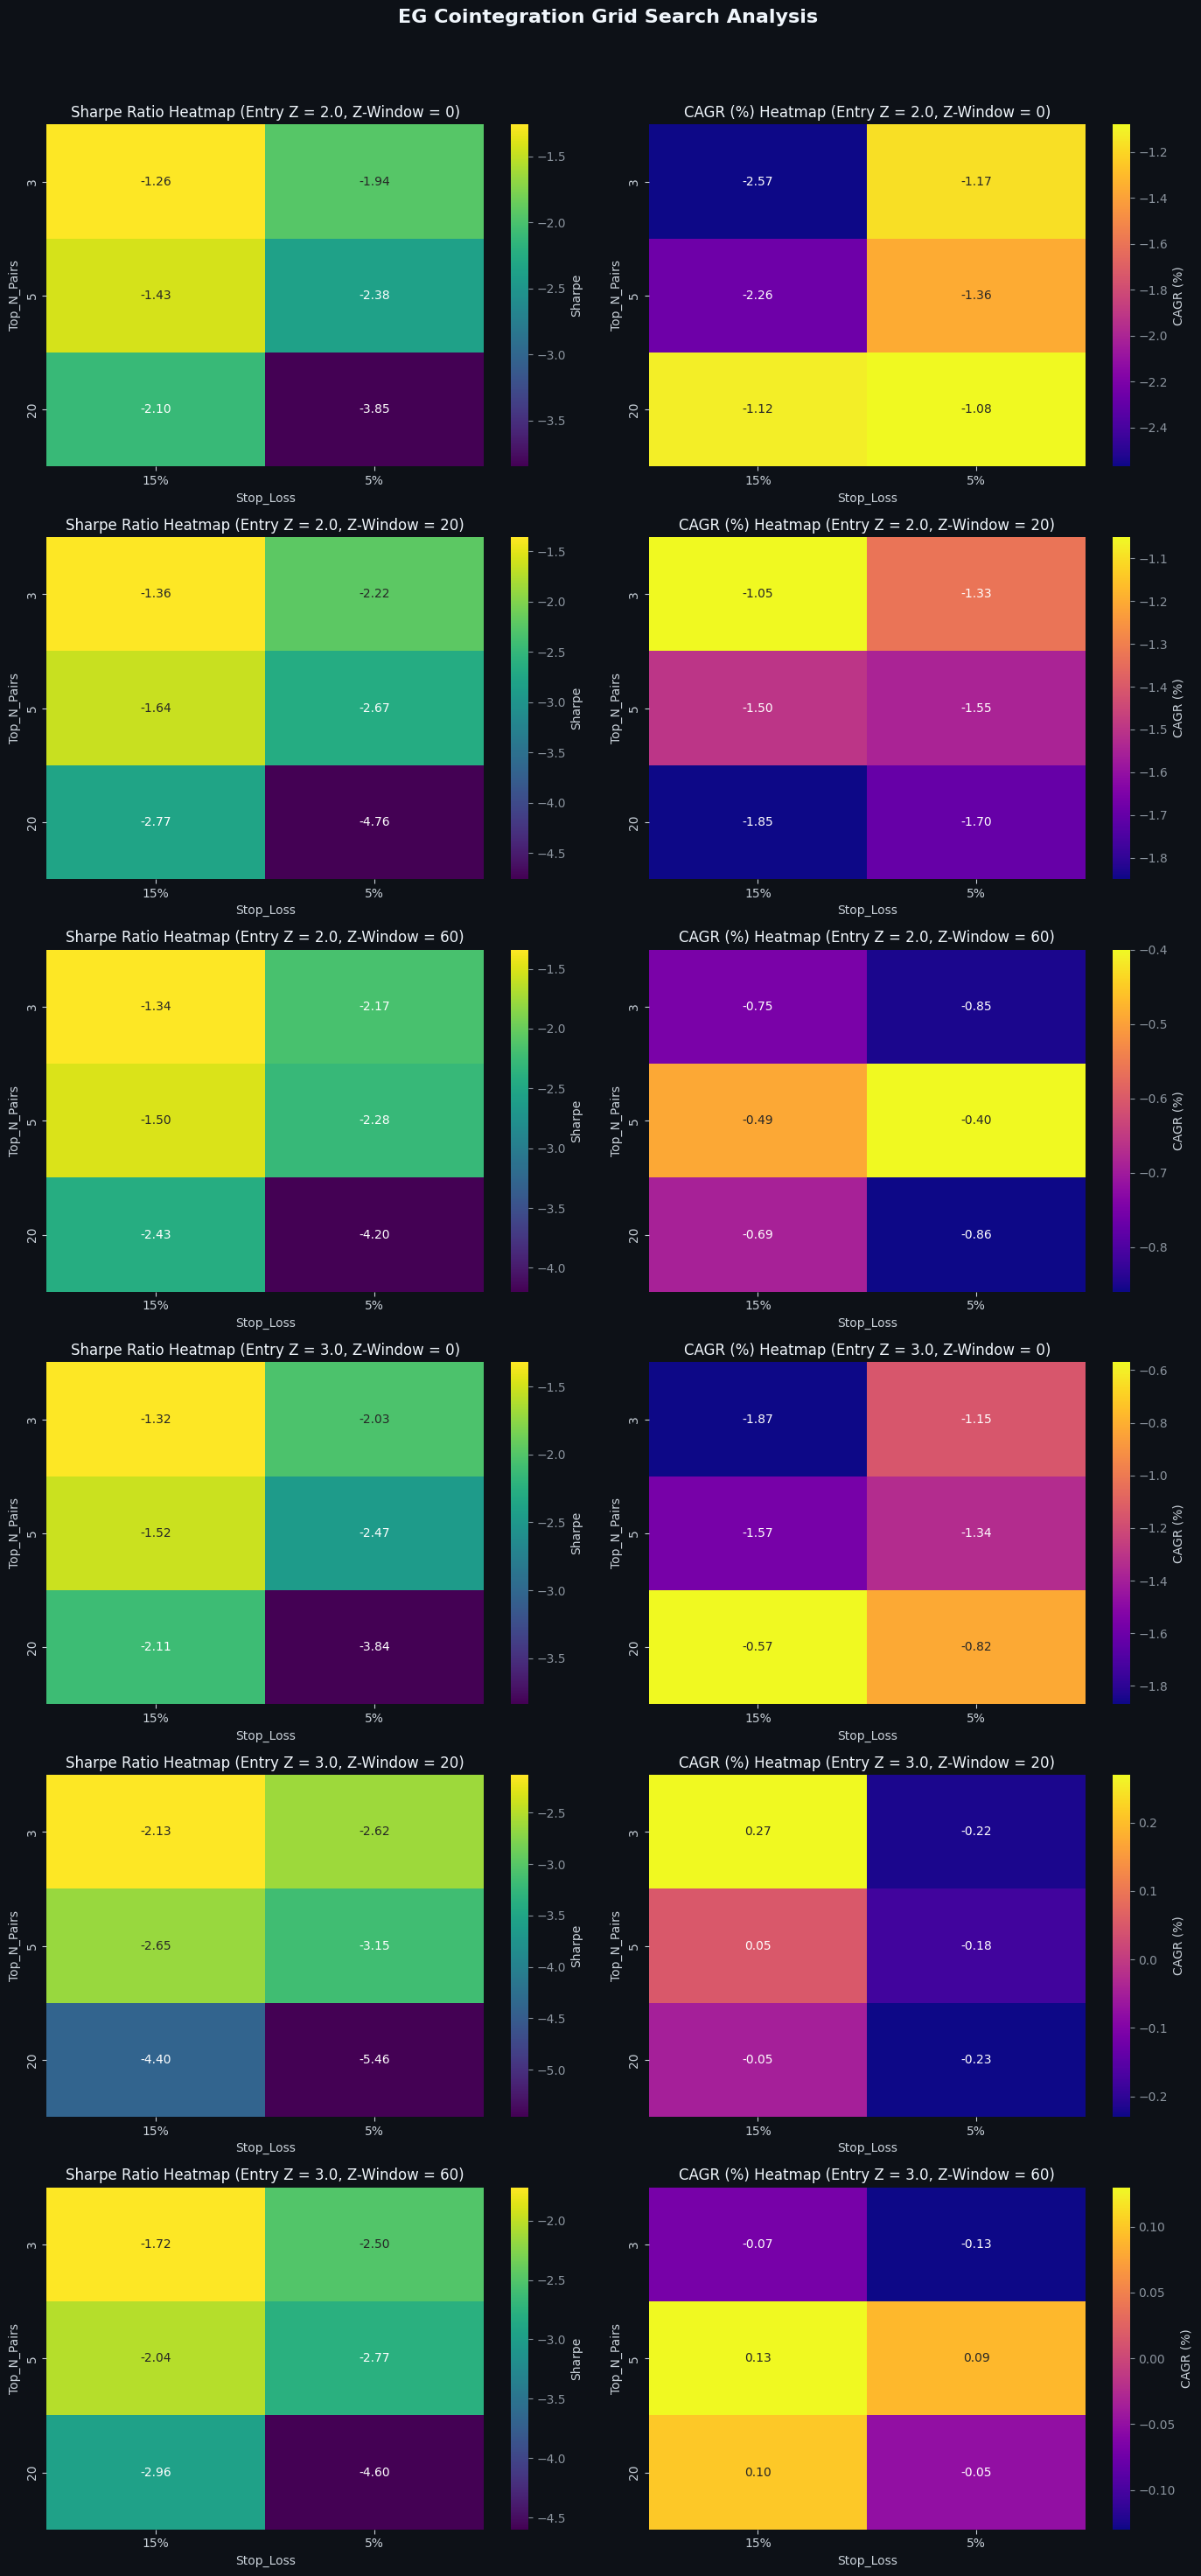

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 主程式：滾動回測 + Grid Search
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    # ── 資料設定 ──────────────────────────────────────────────────────────
    DB_PATH, TABLE_NAME   = r"../data/sp500.db", "daily_prices"
    BACKTEST_START        = "2000-01"
    BACKTEST_END          = "2025-12"
    INFO_TABLE_NAME       = "company_info"
    TICKER_COL_NAME       = "ticker"
    SECTOR_COL_NAME       = "sector"

    # ── Grid Search 參數空間 ──────────────────────────────────────────────
    TOP_N_LIST         = [3, 5, 20]       # 每期最多選取配對數
    STOP_LOSS_LIST     = [0.05, 0.15]  # 停損比例（佔 capital_per_pair）
    ENTRY_Z_LIST       = [2.0, 3.0]    # 進場 Z-Score 門檻
    ZSCORE_WINDOW_LIST = [0, 20, 60]   # 0 表示使用形成期的靜態均值/標準差，大於 0 表示使用滾動視窗

    # ── 固定回測參數 ──────────────────────────────────────────────────────
    FORMATION_WINDOW = 252   # 形成期長度（交易日）
    TRADING_WINDOW   = 126   # 交易期長度（交易日）
    ROLLING_STEP     = 21    # 滾動步長（交易日）
    EXIT_Z           = 0.0   # 出場門檻（Spread 回歸均值）
    MAX_HOLD_DAYS    = 60    # 強制平倉天數上限

    FEE_RATE         = 0.001   # 手續費率
    SLIPPAGE_RATE    = 0.001   # 滑價率
    INITIAL_CAPITAL  = 10000  # 初始資金（USD）

    ALLOW_REENTRY    = False    # 允許停損後再進場
    USE_SECTOR_PAIRING = True # True = 同產業配對；False = 全市場配對

    OUTPUT_DIR = Path(r"../results/EG_Sector")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # ── 資料載入 ──────────────────────────────────────────────────────────
    processor = DataProcessor(db_path=DB_PATH, table_name=TABLE_NAME)

    if USE_SECTOR_PAIRING:
        sector_mapping = processor.load_sector_mapping(
            INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME
        )
    else:
        sector_mapping = {}
        print("ℹ️ 產業分類配對已關閉（USE_SECTOR_PAIRING=False），進行全市場配對。")

    price_pivot, all_dates, total_days, local_first_trade_idx = processor.prepare_backtest_data(
        BACKTEST_START, BACKTEST_END, FORMATION_WINDOW
    )

    # ── 初始化各參數組合的 Performance 物件 ──────────────────────────────
    max_concurrent = TRADING_WINDOW // ROLLING_STEP

    states = {}
    for n, sl, ez, zw in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ENTRY_Z_LIST, ZSCORE_WINDOW_LIST):
        sub_dir = OUTPUT_DIR / f"Top{n}_SL{int(sl*100)}_EZ{int(ez*10)}_ZW{zw}"
        perf    = Performance(initial_capital=INITIAL_CAPITAL, output_dir=sub_dir)
        perf.set_zscore_params(entry_z=ez, exit_z=EXIT_Z)
        states[(n, sl, ez, zw)] = {
            "perf" : perf,
            "slots": [
                {"avail_idx": 0, "capital": INITIAL_CAPITAL / max_concurrent}
                for _ in range(max_concurrent)
            ],
        }

    # ── 滾動回測主迴圈 ────────────────────────────────────────────────────
    roll_start_indices = list(
        range(local_first_trade_idx, total_days - TRADING_WINDOW + 1, ROLLING_STEP)
    )
    n_params = len(list(itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ENTRY_Z_LIST, ZSCORE_WINDOW_LIST)))
    print(f"\n🚀 開始 EG Grid Search，共 {len(roll_start_indices)} 期，每期 {n_params} 種參數組合...")

    for roll_idx, trade_start_idx in enumerate(roll_start_indices):
        form_start_idx = trade_start_idx - FORMATION_WINDOW
        form_end_idx   = trade_start_idx
        trade_end_idx  = min(trade_start_idx + TRADING_WINDOW, total_days)

        form_data  = price_pivot.iloc[form_start_idx:form_end_idx]
        trade_data = price_pivot.iloc[trade_start_idx:trade_end_idx]

        # 僅保留形成期與交易期均無缺失值的股票
        valid_cols = (form_data.isnull().sum() + trade_data.isnull().sum()) == 0
        form_data  = form_data.loc[:, valid_cols]
        trade_data = trade_data.loc[:, valid_cols]

        if form_data.shape[1] < 2 or trade_data.empty:
            continue

        trade_start_str = str(all_dates[trade_start_idx])[:10]
        trade_end_str   = str(all_dates[trade_end_idx - 1])[:10]
        form_start_str  = str(all_dates[form_start_idx])[:10]
        form_end_str    = str(all_dates[form_end_idx - 1])[:10]

        print(f"  ▶ 第 {roll_idx+1:02d} 期 (交易: {trade_start_str} ~ {trade_end_str})", end=" ... ")

        # ── Formation：執行 EG 共整合篩選（以最大 top_n 為基準，各組共用） ──
        formation = Formation(
            price_df       = form_data,
            form_start     = form_start_str,
            form_end       = form_end_str,
            top_n          = max(TOP_N_LIST),
            sector_mapping = sector_mapping,
            max_half_life  = TRADING_WINDOW / 2.0,  # 新增：半衰期過濾門檻
        )
        max_selected_pairs = formation.run()

        if max_selected_pairs.empty:
            print("無共整合配對，跳過。")
            continue

        print(f"找到 {len(max_selected_pairs)} 組共整合配對。")

        # ── Trading：依各參數組合執行交易模擬 ────────────────────────────
        for n, sl, ez, zw in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ENTRY_Z_LIST, ZSCORE_WINDOW_LIST):
            selected_pairs = max_selected_pairs.head(n)
            state  = states[(n, sl, ez, zw)]
            slots  = state["slots"]

            # 選擇可用資金槽（優先選已釋放的槽）
            free_slots = [i for i, s in enumerate(slots) if s["avail_idx"] <= trade_start_idx]
            if free_slots:
                slot_idx = free_slots[0]
            else:
                slot_idx = min(range(max_concurrent), key=lambda i: slots[i]["avail_idx"])

            current_period_capital = slots[slot_idx]["capital"]
            current_capital_per_pair = current_period_capital / n

            trading = Trading(
                price_df         = trade_data,
                selected_pairs   = selected_pairs,
                capital_per_pair = current_capital_per_pair,
                fee_rate         = FEE_RATE,
                slippage_rate    = SLIPPAGE_RATE,
                stop_loss_pct    = sl,
                entry_z          = ez,
                exit_z           = EXIT_Z,
                max_hold_days    = MAX_HOLD_DAYS,
                allow_reentry    = ALLOW_REENTRY,
                zscore_window    = zw,
            )

            trade_log_df, period_daily_delta = trading.run()
            period_pnl = trading.period_pnl if not trade_log_df.empty else 0.0

            # 更新槽位資金與可用時間
            slots[slot_idx]["capital"]   = max(0, current_period_capital + period_pnl)
            slots[slot_idx]["avail_idx"] = trade_end_idx

            state["perf"].add_period(
                trade_start_str, trade_end_str,
                trade_log_df, period_daily_delta,
                current_period_capital, current_capital_per_pair,
            )

    # ── 產生總結報表 ──────────────────────────────────────────────────────
    summary_results = []
    print("\n✅ 回測完成！正在產生總結報表...")

    for (n, sl, ez, zw), state in states.items():
        report = state["perf"].generate_report(quiet=True)
        if report:
            report["Top_N_Pairs"] = n
            report["Stop_Loss"]   = f"{sl*100:.0f}%"
            report["Entry_Z"]     = ez
            report["Z_Window"]    = zw
            summary_results.append(report)

    if not summary_results:
        print("⚠️ 無有效交易紀錄，請檢查資料或參數設定。")
    else:
        summary_df = pd.DataFrame(summary_results)
        cols = [
            "Entry_Z", "Z_Window", "Top_N_Pairs", "Stop_Loss",
            "CAGR (%)", "ExCAGR (%)", "Sharpe Ratio", "Calmar Ratio",
            "Max Drawdown (%)", "Period Win Rate (%)", "Trade Win Rate (%)",
            "Total Trades", "Avg Payoff Ratio", "Avg R_EC (%)",
        ]
        # 保留實際存在的欄位（防止 Calmar 為字串時排序錯誤）
        cols = [c for c in cols if c in summary_df.columns]
        summary_df = summary_df[cols].sort_values("Sharpe Ratio", ascending=False)
        summary_df.to_csv(OUTPUT_DIR / "grid_search_summary.csv", index=False)
        print(f"\n📁 結果已儲存至：{OUTPUT_DIR / 'grid_search_summary.csv'}")
        print(summary_df.to_string(index=False))

        # ── 熱力圖：Sharpe Ratio & CAGR ──────────────────────────────────
        plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
                             "text.color": "#c9d1d9"})
        
        plot_combinations = list(itertools.product(ENTRY_Z_LIST, ZSCORE_WINDOW_LIST))
        fig, axes = plt.subplots(
            len(plot_combinations), 2,
            figsize=(14, 5 * len(plot_combinations)),
            squeeze=False,
        )
        fig.patch.set_facecolor("#0d1117")

        for idx, (ez, zw) in enumerate(plot_combinations):
            df_sub = summary_df[(summary_df["Entry_Z"] == ez) & (summary_df["Z_Window"] == zw)]
            if df_sub.empty:
                continue

            pivot_sharpe  = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="Sharpe Ratio")
            pivot_ann_ret = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="CAGR (%)")

            sns.heatmap(pivot_sharpe, annot=True, cmap="viridis",
                        ax=axes[idx, 0], cbar_kws={"label": "Sharpe"}, fmt=".2f")
            axes[idx, 0].set_title(f"Sharpe Ratio Heatmap (Entry Z = {ez}, Z-Window = {zw})", color="#f0f6fc")
            axes[idx, 0].tick_params(colors="#c9d1d9")

            sns.heatmap(pivot_ann_ret, annot=True, cmap="plasma",
                        ax=axes[idx, 1], cbar_kws={"label": "CAGR (%)"}, fmt=".2f")
            axes[idx, 1].set_title(f"CAGR (%) Heatmap (Entry Z = {ez}, Z-Window = {zw})", color="#f0f6fc")
            axes[idx, 1].tick_params(colors="#c9d1d9")

        plt.suptitle("EG Cointegration Grid Search Analysis",
                     color="#f0f6fc", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=(0, 0, 1, 0.96))
        heatmap_file = OUTPUT_DIR / "grid_search_heatmap.png"
        fig.savefig(heatmap_file, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.show()